In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install transformers==4.41.2 --no-deps
!pip install tokenizers==0.19.1 --no-deps  # Compatible version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.3 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 35.0 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2


In [2]:
# Data download and preprocessing for AG News (Text Classification)
from datasets import load_dataset
from transformers import AutoTokenizer
from pympler import asizeof
from torch.utils.data import DataLoader
from collections import Counter

# Load ag-news dataset
ag_news_dataset = load_dataset("ag_news")

# Function to filter out invalid labels (if any)
def filter_valid(example):
    return example["label"] != -1

# Filter all splits
ag_news_dataset = {
    split: ds.filter(filter_valid) if "test" not in split else ds
    for split, ds in ag_news_dataset.items()
}


# Check the dataset structure
print(ag_news_dataset)

split = ag_news_dataset["train"].train_test_split(
    test_size=0.1,
    seed=42,
    stratify_by_column="label",
    shuffle=True
)


# Create train dataset
train_dataset = split["train"]
validation_dataset = split["test"]
test_dataset = ag_news_dataset["test"]

print(f"\nExample from training set:")
print(train_dataset[0])
print(validation_dataset[0])
print(test_dataset[0])

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize function with dynamic padding for sentence pairs
def tokenize_function(example):
    return tokenizer(
        example["text"],  
        padding=False,  # No padding during tokenization
        truncation=True,
        max_length=128
    )

# Tokenize each dataset separately
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_validation = validation_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Change dataset format to use "labels" instead of "label"
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_validation = tokenized_validation.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

# Set format for PyTorch
tokenized_train.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_validation.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])

# Print dataset information
print(f"\nTrain dataset size: {len(tokenized_train)}")
print(f"Validation dataset size: {len(tokenized_validation)} (half of original dev set)")
print(f"Test dataset size: {len(tokenized_test)} (other half of original dev set)")

# Attention mask check
print(f"\nAttention mask example: {tokenized_train[0]['attention_mask']}")

# Check the train dataset dtype and size
size_in_bytes = asizeof.asizeof(tokenized_train)
size_in_mb = size_in_bytes / (1024 * 1024)
print(f"\nTotal size of tokenized_train: {size_in_mb:.2f} MB")


# Check label distribution
train_labels = [label.item() for label in tokenized_train["labels"]]
validation_labels = [label.item() for label in tokenized_validation["labels"]]
test_labels = [label.item() for label in tokenized_test["labels"]]
print(f"\nLabel distribution in train: {Counter(train_labels)}")
print(f"Label distribution in validation: {Counter(validation_labels)}")
print(f"Label distribution in test: {Counter(test_labels)}")


# Check data types and shapes
print(f"\nData type and shape information:")
print(f"input_ids - shape: {tokenized_train[0]['input_ids'].shape}, dtype: {tokenized_train[0]['input_ids'].dtype}")
print(f"token_type_ids - shape: {tokenized_train[0]['token_type_ids'].shape}, dtype: {tokenized_train[0]['token_type_ids'].dtype}")
print(f"attention_mask - shape: {tokenized_train[0]['attention_mask'].shape}, dtype: {tokenized_train[0]['attention_mask'].dtype}")
print(f"labels - shape: {tokenized_train[0]['labels'].shape}, dtype: {tokenized_train[0]['labels'].dtype}")

# Check data types of each column
print("\nColumn data types:")
sample = tokenized_train[0]
for key, value in sample.items():
    print(f"Column: {key}, Data Type: {value.dtype}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]


Train dataset size: 108000
Validation dataset size: 12000 (half of original dev set)
Test dataset size: 7600 (other half of original dev set)

Attention mask example: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1])

Total size of tokenized_train: 119.02 MB

Label distribution in train: Counter({1: 27000, 3: 27000, 2: 27000, 0: 27000})
Label distribution in validation: Counter({2: 3000, 0: 3000, 3: 3000, 1: 3000})
Label distribution in test: Counter({2: 1900, 3: 1900, 1: 1900, 0: 1900})

Data type and shape information:
input_ids - shape: torch.Size([49]), dtype: torch.int64
token_type_ids - shape: torch.Size([49]), dtype: torch.int64
attention_mask - shape: torch.Size([49]), dtype: torch.int64
labels - shape: torch.Size([]), dtype: torch.int64

Column data types:
Column: labels, Data Type: torch.int64
Column: input_ids, Data Type: torch.int64
Column: token_type_i

In [4]:
import torch
import torch.nn as nn
import inspect
from transformers import BertConfig, BertForSequenceClassification

class BertForAG(nn.Module):
    def __init__(self, vocab_size=30522, num_labels=4):
        super().__init__()
        
        # === Custom BERT config (~23M params) ===
        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=384,
            num_hidden_layers=6,
            num_attention_heads=6,
            intermediate_size=1536,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
            max_position_embeddings=512,
            type_vocab_size=2,
            num_labels=num_labels   
        )
        
        # Classification head instead of MLM
        self.model = BertForSequenceClassification(config)
        

    def forward(self, input_ids, attention_mask=None, labels=None):
        """
        Forward pass for NLI (sequence classification).
        Returns logits + loss (if labels are provided).
        """
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        return outputs.logits, outputs.loss 

    def configure_optimizers(self, weight_decay, learning_rate, device="cuda", verbose=False):
        """
        AdamW optimizer with weight decay only on weight matrices.
        """
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}

        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]

        optim_groups = [
            {"params": decay_params, "weight_decay": weight_decay},
            {"params": nodecay_params, "weight_decay": 0.0},
        ]

        fused_available = "fused" in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and "cuda" in device

        if verbose:
            num_decay = sum(p.numel() for p in decay_params)
            num_nodecay = sum(p.numel() for p in nodecay_params)
            print(f"decay params: {len(decay_params)} tensors, {num_decay/1e6:.2f}M params")
            print(f"nodecay params: {len(nodecay_params)} tensors, {num_nodecay/1e6:.2f}M params")
            print(f"Using fused AdamW: {use_fused}")

        optimizer = torch.optim.AdamW(
            optim_groups,
            lr=learning_rate,
            betas=(0.9, 0.999),
            eps=1e-8,
            fused=use_fused
        )
        return optimizer



# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seeds for reproducibility
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

# Initialize the model
model = BertForAG(num_labels=4)
model = model.to(device)

total_params = sum(param.numel() for param in model.parameters())
print(f"Total number of parameters: {total_params/1e6}M")


#TF16
torch.set_float32_matmul_precision('high')

Total number of parameters: 22.714756M


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
from tqdm import tqdm
import time
import math
from datetime import datetime, timezone
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Data Loader
batch_size = 256

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

train_dataloader = DataLoader(
    tokenized_train,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)
val_dataloader = DataLoader(
    tokenized_validation,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)


# Quick check
print(f"Training batches: {len(train_dataloader)}") 
print(f"Validation batches: {len(val_dataloader)}")

#--------------------------------------- Training hyperparameters ---------------------------------
num_epochs = 4  # AG News typically needs fewer epochs than STS-B
max_steps = num_epochs * len(train_dataloader)
grad_clip = 1.0
eval_interval = 250  
log_interval = 50    # Log every 50 steps

# Learning rate setup
max_lr = 1e-4  # Higher learning rate for classification
min_lr = 1e-5
warmup_steps = int(0.1 * max_steps)
plateau = int(0.4 * max_steps)

def get_lr(it):
    if it < warmup_steps:
        return max_lr * (it + 1) / warmup_steps
    if it < plateau:
        return max_lr
    if it > max_steps:
        return min_lr
    decay_ratio = (it - plateau) / (max_steps - plateau)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)

optimizer = model.configure_optimizers(weight_decay=0.01, learning_rate=max_lr, device=device, verbose=True)

# History tracking
train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []
steps_history = []


def evaluate(dataloader, split_name):
    """Evaluation function for classification with accuracy and F1"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc=f"Evaluating {split_name}",
                        leave=True, position=0, ncols=80,
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()

            # Forward pass
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

            # Get predictions (argmax for classification)
            preds = torch.argmax(logits, dim=-1)
            
            # Collect predictions and labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total_loss += loss.item()

            progress_bar.set_postfix(loss=f"{loss.item():.4f}", refresh=False)

    # Calculate metrics
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')  # Macro F1 for multi-class

    print(f"\n{split_name} Results | Loss: {avg_loss:.4f} | "
          f"Accuracy: {accuracy:.4f} | Macro F1: {f1:.4f}")

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "f1": f1
    }


def plot_training_history():
    """Plot training and validation metrics."""
    plt.figure(figsize=(12, 10))

    # Plot losses
    plt.subplot(3, 1, 1)
    plt.plot(steps_history, train_losses, label='Train Loss')
    plt.plot(steps_history, val_losses, label='Val Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(3, 1, 2)
    plt.plot(steps_history, val_accuracies, label='Val Accuracy', color='green')
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot F1 Score
    plt.subplot(3, 1, 3)
    plt.plot(steps_history, val_f1_scores, label='Val Macro F1', color='orange')
    plt.xlabel('Steps')
    plt.ylabel('Macro F1 Score')
    plt.title('Validation Macro F1 Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()
    print("Training history plot saved to 'training_history.png'")


def train():
    global_step = 0
    best_val_acc = 0.0
    start_time = time.time()

    global train_losses, val_losses, val_accuracies, val_f1_scores, steps_history

    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Starting epoch {epoch+1}/{num_epochs}")
        print(f"{'='*60}")
        model.train()
        epoch_losses = []

        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")
        for batch in progress_bar:
            if global_step >= max_steps:
                break

            t0 = time.time()

            # Get batch data
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()

            optimizer.zero_grad()

            # Forward pass
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

            # Backward pass
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            # Update learning rate
            lr = get_lr(global_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            optimizer.step()

            current_loss = loss.item()
            epoch_losses.append(current_loss)

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            t1 = time.time()
            dt = (t1 - t0)
            tokens_processed = input_ids.size(0) * input_ids.size(1)
            tokens_per_sec = tokens_processed / dt

            progress_bar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'lr': f'{lr:.2e}',
                'tok/s': f'{tokens_per_sec:.0f}'
            })

            if global_step % log_interval == 0:
                print(f'\nstep {global_step:6d} | loss: {current_loss:.6f} | lr: {lr:.4e} | '
                      f'dt: {dt*1000:.2f}ms | norm: {norm:.4f} | tok/sec: {tokens_per_sec:.2f}')

            # Evaluation
            if global_step > 0 and global_step % eval_interval == 0:
                print(f"\n{'='*60}")
                print(f"Evaluating at step {global_step}...")
                print(f"{'='*60}")
                val_metrics = evaluate(val_dataloader, "Validation")

                # Use accuracy as main metric for classification
                val_acc = val_metrics["accuracy"]

                # Track metrics
                avg_train_loss = sum(epoch_losses[-100:]) / min(len(epoch_losses), 100)
                train_losses.append(avg_train_loss)
                val_losses.append(val_metrics["loss"])
                val_accuracies.append(val_metrics["accuracy"])
                val_f1_scores.append(val_metrics["f1"])
                steps_history.append(global_step)

                # Save best model
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    torch.save(model.state_dict(), "best_model.pt")
                    print(f"✓ New best validation accuracy: {best_val_acc:.4f}")

                plot_training_history()
                model.train()
                print("")

            global_step += 1

        epoch_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"\nEpoch {epoch+1} completed | Average loss: {epoch_loss:.6f}")
    
    # Save final model
    torch.save(model.state_dict(), "final_model.pt")
    end_time = time.time()
    elapsed = end_time - start_time
    elapsed_str = datetime.fromtimestamp(elapsed, tz=timezone.utc).strftime("%H:%M:%S")
    
    print(f"\n{'='*60}")
    print("Training Summary")
    print(f"{'='*60}")
    print(f"Training completed in {elapsed:.2f} seconds ({elapsed_str})")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    print("Final model saved to 'final_model.pt'")
    print("Best model saved to 'best_model.pt'")

2026-01-05 17:04:05.088932: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767632645.306827      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767632645.366795      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Training batches: 422
Validation batches: 47
decay params: 41 tensors, 22.68M params
nodecay params: 64 tensors, 0.03M params
Using fused AdamW: True


In [6]:
train()


Starting epoch 1/4


Epoch 1:   0%|          | 0/422 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2717: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
Epoch 1:   0%|          | 1/422 [00:01<09:52,  1.41s/it, loss=1.3965, lr=5.95e-07, tok/s=24550]


step      0 | loss: 1.396484 | lr: 5.9524e-07 | dt: 1334.74ms | norm: 1.1247 | tok/sec: 24550.09


Epoch 1:  12%|█▏        | 51/422 [00:30<03:39,  1.69it/s, loss=1.3857, lr=3.04e-05, tok/s=60085]


step     50 | loss: 1.385681 | lr: 3.0357e-05 | dt: 545.36ms | norm: 0.9419 | tok/sec: 60085.44


...


step   1600 | loss: 0.140746 | lr: 1.1665e-05 | dt: 545.35ms | norm: 1.4876 | tok/sec: 60085.83


Epoch 4:  91%|█████████ | 385/422 [03:59<00:21,  1.69it/s, loss=0.1938, lr=1.03e-05, tok/s=60076]


step   1650 | loss: 0.193830 | lr: 1.0312e-05 | dt: 545.44ms | norm: 3.2741 | tok/sec: 60075.85


Epoch 4: 100%|██████████| 422/422 [04:20<00:00,  1.62it/s, loss=0.1846, lr=1.00e-05, tok/s=59863]


Epoch 4 completed | Average loss: 0.127660

Training Summary
Training completed in 1067.36 seconds (00:17:47)
Best validation accuracy: 0.9183
Final model saved to 'final_model.pt'
Best model saved to 'best_model.pt'


Test batches: 30
Loading best model...
Model loaded successfully!


Starting final evaluation on test set...


Evaluating Test Set:   0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2717: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



                Test Set EVALUATION RESULTS                 
Loss: 0.2670
Accuracy: 0.9168 (6968/7600)
F1 Score (Macro): 0.9169
F1 Score (Weighted): 0.9169
F1 Score (Micro): 0.9168

               CONFUSION MATRIX VISUALIZATION               


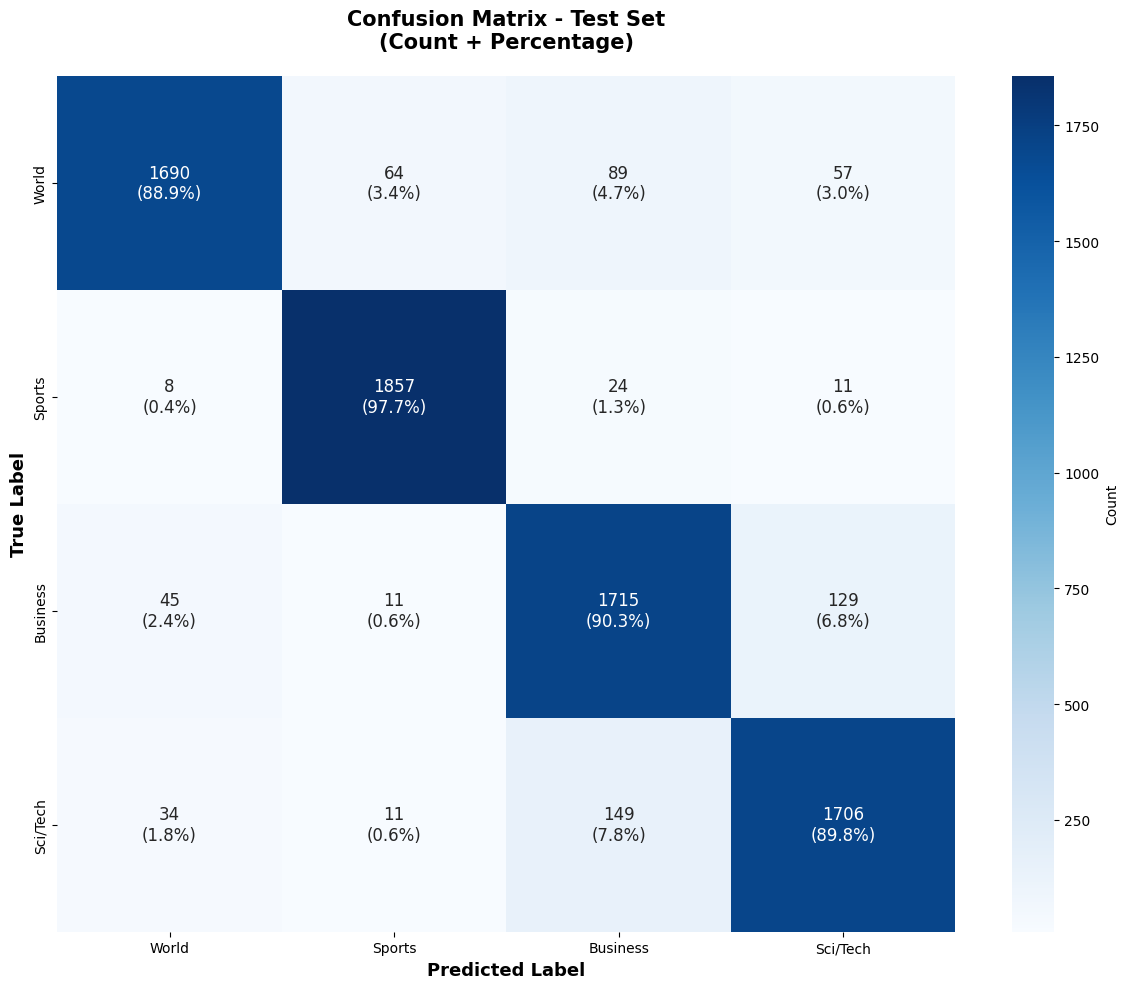

Confusion matrix saved to: confusion_matrix_test_set_20260105_172621.png

                   CLASSIFICATION REPORT                    
              precision    recall  f1-score   support

       World     0.9510    0.8895    0.9192      1900
      Sports     0.9557    0.9774    0.9664      1900
    Business     0.8675    0.9026    0.8847      1900
    Sci/Tech     0.8965    0.8979    0.8972      1900

    accuracy                         0.9168      7600
   macro avg     0.9177    0.9168    0.9169      7600
weighted avg     0.9177    0.9168    0.9169      7600

                 PER-CLASS DETAILED METRICS                 

World:
  Accuracy:  0.8895 (1690/1900)
  Precision: 0.9510
  Recall:    0.8895
  F1 Score:  0.9192
  Support:   1900 samples

Sports:
  Accuracy:  0.9774 (1857/1900)
  Precision: 0.9557
  Recall:    0.9774
  F1 Score:  0.9664
  Support:   1900 samples

Business:
  Accuracy:  0.9026 (1715/1900)
  Precision: 0.8675
  Recall:    0.9026
  F1 Score:  0.8847
  Support:   

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score, classification_report, precision_recall_fscore_support

test_dataloader = DataLoader(
    tokenized_test,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

print(f"Test batches: {len(test_dataloader)}")

def final_evaluation(model, dataloader, split_name, class_names=None, device=None):
    if device is None:
        device = next(model.parameters()).device
    
    if class_names is None:
        class_names = ["World", "Sports", "Business", "Sci/Tech"]  # AG News classes
    
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    num_examples = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {split_name}", leave=False):
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()
            
            # Forward pass with autocast
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
            
            # Compute predictions
            preds = torch.argmax(logits, dim=-1)
            
            # Track predictions and labels
            batch_size = input_ids.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            total_loss += loss.item() * batch_size
            num_examples += batch_size
    
    # Convert to numpy arrays for sklearn
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate basic metrics
    correct = np.sum(y_true == y_pred)
    accuracy = correct / len(y_true)
    avg_loss = total_loss / num_examples  # Weighted average by batch size
    
    # Calculate F1 scores (macro is standard for multi-class)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    f1_micro = f1_score(y_true, y_pred, average='micro')  # Same as accuracy for multi-class
    
    # Calculate precision, recall, F1 per class
    precision, recall, f1_per_class, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1, 2, 3]
    )
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    
    # Per-class metrics
    per_class_metrics = {}
    for cls_idx, cls_name in enumerate(class_names):
        cls_indices = np.where(y_true == cls_idx)[0]
        cls_correct = np.sum(y_pred[cls_indices] == y_true[cls_indices])
        cls_acc = cls_correct / len(cls_indices) if len(cls_indices) > 0 else 0
        per_class_metrics[cls_name] = {
            "accuracy": cls_acc,
            "precision": precision[cls_idx],
            "recall": recall[cls_idx],
            "f1": f1_per_class[cls_idx],
            "support": int(support[cls_idx]),
            "correct": int(cls_correct),
            "total": len(cls_indices)
        }
    
    # Print metrics
    print(f"\n{'='*60}")
    print(f"{split_name} EVALUATION RESULTS".center(60))
    print(f"{'='*60}")
    print(f"Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f} ({correct}/{len(y_true)})")
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")
    print(f"F1 Score (Micro): {f1_micro:.4f}")
    
    # Enhanced confusion matrix visualization
    print(f"\n{'='*60}")
    print("CONFUSION MATRIX VISUALIZATION".center(60))
    print(f"{'='*60}")
    
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    plt.figure(figsize=(12, 10))
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create custom annotations with count + percentage
    annotations = []
    for i in range(cm.shape[0]):
        row = []
        for j in range(cm.shape[1]):
            row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
        annotations.append(row)
    
    sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 12})
    plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
    plt.ylabel('True Label', fontsize=13, fontweight='bold')
    plt.title(f'Confusion Matrix - {split_name}\n(Count + Percentage)', 
              fontsize=15, fontweight='bold', pad=20)
    plt.tight_layout()
    
    plot_filename = f'confusion_matrix_{split_name.lower().replace(" ", "_")}_{timestamp}.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Confusion matrix saved to: {plot_filename}")
    
    # Print classification report
    print(f"\n{'='*60}")
    print("CLASSIFICATION REPORT".center(60))
    print(f"{'='*60}")
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(report)
    
    # Print per-class detailed metrics
    print(f"{'='*60}")
    print("PER-CLASS DETAILED METRICS".center(60))
    print(f"{'='*60}")
    for cls_name, stats in per_class_metrics.items():
        print(f"\n{cls_name}:")
        print(f"  Accuracy:  {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")
        print(f"  Precision: {stats['precision']:.4f}")
        print(f"  Recall:    {stats['recall']:.4f}")
        print(f"  F1 Score:  {stats['f1']:.4f}")
        print(f"  Support:   {stats['support']} samples")
    
    print(f"\n{'='*60}\n")
    
    # Return comprehensive metrics
    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_micro": f1_micro,
        "confusion_matrix": cm.tolist(),
        "per_class_metrics": per_class_metrics
    }


# ============================================================================
# MAIN EVALUATION SCRIPT
# ============================================================================

# Load the saved model weights
print("Loading best model...")
model = BertForAG(num_labels=4)# Initialize model with the same config
model.load_state_dict(torch.load("best_model.pt"))  # Load the best weights
model = model.to(device)  # Move model to the appropriate device
model.eval()  # Set model to evaluation mode
print("Model loaded successfully!\n")

# Define class names for AG News
class_names = ["World", "Sports", "Business", "Sci/Tech"]

# Run final evaluation on test set
print("\nStarting final evaluation on test set...")
test_metrics = final_evaluation(
    model=model,
    dataloader=test_dataloader,
    split_name="Test Set",
    class_names=class_names,
    device=device
)

# Print summary of key metrics
print("\n" + "="*60)
print("FINAL TEST SET SUMMARY".center(60))
print("="*60)
print(f"Loss:              {test_metrics['loss']:.4f}")
print(f"Accuracy:          {test_metrics['accuracy']:.4f}")
print(f"F1 (Macro):        {test_metrics['f1_macro']:.4f}")
print(f"F1 (Weighted):     {test_metrics['f1_weighted']:.4f}")
print(f"F1 (Micro):        {test_metrics['f1_micro']:.4f}")
print("\nPer-Class Metrics:")
for cls_name, stats in test_metrics['per_class_metrics'].items():
    print(f"  {cls_name:12s}: Acc={stats['accuracy']:.4f}, "
          f"P={stats['precision']:.4f}, R={stats['recall']:.4f}, F1={stats['f1']:.4f}")
print("="*60)
